In [63]:
from typing import Tuple, List

import os
import rootutils

from tqdm import tqdm

rootutils.setup_root(os.path.abspath('./'), indicator=".project-root", pythonpath=True, dotenv=True, cwd=True)

# auto-loading of imports from outside scripts
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
from src.utils import create_df, compute_fingerprints, compute_descriptors, create_data, eval_metrics, plot_pred_true, plot_importance
from src.avail_descriptors import descriptors_all, descriptors_short

In [65]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from argparse import Namespace

from sklearn.model_selection import train_test_split

---
# Feature Extraction:

In [66]:
data_path = "data/Bradley_dataset_ok_3"
columns = ['line_number', 'smiles', 'cas', 'label', 'T']

df = create_df(data_path, columns)

In [67]:
data_args = {
    "descriptors": descriptors_all,

    "apply_norm": False,
    
    "create_fingerprints": False,
    "temp_column": True,
}

### Computing Features (load, if already precomputed)

In [68]:
from src.utils import create_or_load_data

In [69]:
X, labels, temp = X_bradley, labels_bradley, temp_bradley = create_or_load_data(df, data_args, 'saved_np_obj/Bradley')

Loading data from saved_np_obj/Bradley


### If you want to simulate NaNs in the temperature:

In [70]:
nan_proba = 0.8

np.random.seed(42)
mask = np.random.choice([True, False], size=temp.shape, p=[nan_proba, 1 - nan_proba])
temp_with_nans = temp.copy()
temp_with_nans[mask] = np.nan

In [71]:
temp = temp_with_nans

In [72]:
labels

array([0, 0, 0, ..., 0, 0, 1])

---
# MultiTask Learning with Lightning:

In [79]:
from src.multitask_nn import MultiTaskModel, create_datasets

from lightning.pytorch.callbacks import Callback, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning import seed_everything, Trainer
from torch.utils.data import DataLoader

from datetime import datetime

In [80]:
seed_everything(42, verbose=False)

42

In [102]:
cfg = Namespace(
    project_name="bradley",
    
    normalize_data=True,
    train_size=0.8,

    batch_size=512,
    lr=1e-4,
    max_epochs=20,

    hid_dim=128,
    depth=2,
    use_residual=True,
    drop=0.2,

    cl_loss_coef=1.,
    pos_label_weight=1.5,
    reg_loss_coef=1e-4,

    num_workers=0,
    persistent_workers=False,
)

In [103]:
train_data, val_data = create_datasets(X, labels, temp, use_norm=cfg.normalize_data, train_size=cfg.train_size)

# persistent_workers=True reduces overhead of creating workers
train_loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)
val_loader = DataLoader(val_data, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)

In [104]:
input_dim = X.shape[1]
model = MultiTaskModel(
    input_dim=input_dim,

    hidden_dim=cfg.hid_dim,
    depth=cfg.depth,
    use_residual=cfg.use_residual,
    drop=cfg.drop,

    lr=cfg.lr,

    cl_loss_coef=cfg.cl_loss_coef,
    pos_label_weight=cfg.pos_label_weight,
    reg_loss_coef=cfg.reg_loss_coef
)

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

logger = TensorBoardLogger(
    save_dir="tb_logs/", name=cfg.project_name
)

checkpoint_callback = ModelCheckpoint(
    dirpath=f"checkpoints/{cfg.project_name}-{current_date}",
    filename="{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,
    monitor="V_tot",
    mode="min",
    save_last=True,
)

trainer = Trainer(
    logger=logger,
    callbacks=[checkpoint_callback],
    max_epochs=cfg.max_epochs,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [105]:
trainer.fit(model, train_loader, val_loader)


  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | shared       | Sequential        | 28.9 K | train
1 | classifier   | Sequential        | 16.6 K | train
2 | regressor    | Sequential        | 16.6 K | train
3 | val_accuracy | BinaryAccuracy    | 0      | train
4 | val_f1       | BinaryF1Score     | 0      | train
5 | val_roc_auc  | BinaryAUROC       | 0      | train
6 | val_r2_class | R2Score           | 0      | train
7 | val_mse      | MeanSquaredError  | 0      | train
8 | val_mae      | MeanAbsoluteError | 0      | train
9 | val_r2_reg   | R2Score           | 0      | train
-----------------------------------------------------------
62.2 K    Trainable params
0         Non-trainable params
62.2 K    Total params
0.249     Total estimated model params size (MB)
28        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/avarlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/avarlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/avarlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (41) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


### Doing T(distance) plot:

In [106]:
from src.plot_utils import plot_T_from_distance_for_nn

Computing T(distance) plot: 100%|██████████| 11/11 [00:00<00:00, 132.57it/s]


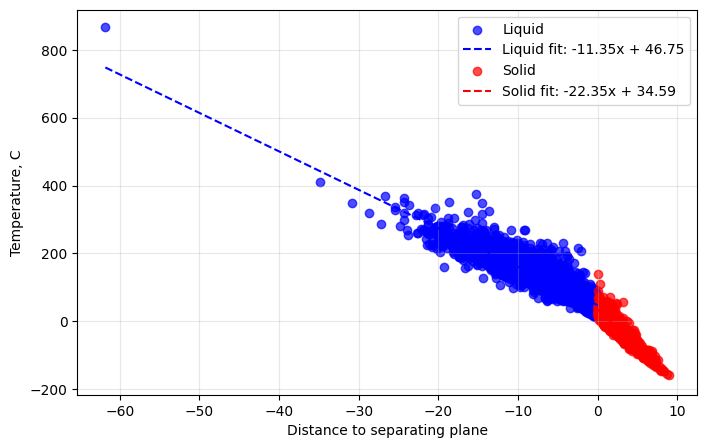

In [107]:
plot_T_from_distance_for_nn(model, val_loader)

---
# Comparing to catboost:

In [108]:
raise Exception("stop")

Exception: stop

In [26]:
from catboost import CatBoostClassifier, CatBoostRegressor
from src.utils import eval_metrics

In [38]:
X_train, X_val, y_train, y_val, temp_train, temp_val = train_test_split(X, labels, temp, train_size=cfg.train_size)

In [ ]:
y_train

array([0, 0, 0, ..., 1, 0, 0])

In [40]:
y_train = y_train[~np.isnan(temp_train)]
y_val = y_val[~np.isnan(temp_val)]

X_train = X_train[~np.isnan(temp_train)]
X_val = X_val[~np.isnan(temp_val)]

temp_train = temp_train[~np.isnan(temp_train)]
temp_val = temp_val[~np.isnan(temp_val)]


In [41]:
catboost_reg = CatBoostRegressor(
    # iterations=1000,
    # depth=10,
    # learning_rate=0.01,
    verbose=100,
)

catboost_reg.fit(X_train, temp_train)
temp_pred = catboost_reg.predict(X_val)

Learning rate set to 0.051123
0:	learn: 95.7315761	total: 2.9ms	remaining: 2.9s
100:	learn: 46.6774211	total: 177ms	remaining: 1.58s
200:	learn: 43.0343689	total: 347ms	remaining: 1.38s
300:	learn: 40.3294908	total: 525ms	remaining: 1.22s
400:	learn: 37.8810419	total: 814ms	remaining: 1.22s
500:	learn: 35.8029582	total: 1s	remaining: 998ms
600:	learn: 34.2037455	total: 1.17s	remaining: 778ms
700:	learn: 32.7957594	total: 1.34s	remaining: 572ms
800:	learn: 31.5415409	total: 1.5s	remaining: 374ms
900:	learn: 30.5408614	total: 1.67s	remaining: 183ms
999:	learn: 29.5327843	total: 1.83s	remaining: 0us


In [ ]:
eval_metrics(temp_val, temp_pred, type="regression")

{'MSE': 1731.258048188205, 'MAE': 31.24016615282138, 'R2': 0.824776635673477}

In [43]:
catboost_cl = CatBoostClassifier(
    # iterations=1000,
    # depth=10,
    # learning_rate=0.01,
    verbose=100,
)

catboost_cl.fit(X_train, y_train)
y_pred = catboost_cl.predict(X_val)

Learning rate set to 0.018774
0:	learn: 0.6704096	total: 3.63ms	remaining: 3.63s
100:	learn: 0.2074158	total: 211ms	remaining: 1.88s
200:	learn: 0.1737876	total: 423ms	remaining: 1.68s
300:	learn: 0.1572521	total: 629ms	remaining: 1.46s
400:	learn: 0.1450105	total: 838ms	remaining: 1.25s
500:	learn: 0.1327919	total: 1.05s	remaining: 1.04s
600:	learn: 0.1219254	total: 1.26s	remaining: 837ms
700:	learn: 0.1123347	total: 1.47s	remaining: 627ms
800:	learn: 0.1037508	total: 1.7s	remaining: 423ms
900:	learn: 0.0958386	total: 1.93s	remaining: 212ms
999:	learn: 0.0899841	total: 2.17s	remaining: 0us


In [ ]:
eval_metrics(y_val, y_pred, type="classification")

{'ACC': 0.9266480965645311,
 'F1': 0.837782340862423,
 'BAL-ACC': 0.880086321946787,
 'ROC-AUC': 0.880086321946787,
 'R2': 0.5973393531533067}